In [1]:
import pandas as pd
import numpy as np
import datetime as dt

1. Data hygiene. Load both files. Check that every customer_id in orders exists in customers. Find any orders dated before their customer's signup date — these are data quality bugs you'll need to decide how to handle. How many duplicate orders are there (same customer, same date, same value)?

In [11]:
customers = pd.read_csv('./Retention Analysis/data/customers.csv')
orders = pd.read_csv('./Retention Analysis/data/orders.csv')

orders.customer_id.count() == orders[orders.customer_id.isin(customers.customer_id)].customer_id.count()
print(f"There are {orders.customer_id.nunique()} customers who have placed an order")

df = pd.merge(customers, orders, on ='customer_id', how='left')

print(f"There have been {df[df.order_date < df.signup_date].order_id.nunique()} orders placed before the customer signed up")

df[['signup_date', 'order_date']] = df[['signup_date', 'order_date']].apply(pd.to_datetime)

# No duplicate rows, no orders by customers no in the orders dataset

df.info()


There are 1931 customers who have placed an order
There have been 5 orders placed before the customer signed up
<class 'pandas.DataFrame'>
RangeIndex: 6342 entries, 0 to 6341
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          6342 non-null   str           
 1   signup_date          6342 non-null   datetime64[us]
 2   acquisition_channel  6342 non-null   str           
 3   country              6342 non-null   str           
 4   order_id             6273 non-null   str           
 5   order_date           6273 non-null   datetime64[us]
 6   order_value          6273 non-null   float64       
 7   num_items            6273 non-null   float64       
dtypes: datetime64[us](2), float64(2), str(4)
memory usage: 396.5 KB


2. Customer lifetime value (basic). For each customer, compute total spend, order count, average order value, and days between first and last order. What's the distribution look like? (Mean vs. median — which one is misleading and why?)

In [12]:
customer_agg = df.groupby(df.customer_id). \
    agg({'order_value':['sum','mean'],'order_id':'nunique','order_date':['max','min']})

customer_agg['Lifetime'] = customer_agg[('order_date','max')] - customer_agg[('order_date','min')]

customer_agg.columns = customer_agg.columns.droplevel(0)

customer_agg.columns = ['Total Spend','Average Order Value','Order Count','Last Order Date','First Order Date','Days Between First and Last Order']

customer_agg.drop(columns=['First Order Date', 'Last Order Date']).describe()
# customer_agg.drop(columns=['First Order Date', 'Last Order Date']).median(axis=0)

# STD is Higher than the Mean for Total Spend and Days Between First and Last Order
# Implies those distributions are skewed or abnormal

customer_agg


,Total Spend,Average Order Value,Order Count,Last Order Date,First Order Date,Days Between First and Last Order
customer_id,,,,,,
C00001,184.29,61.430000,3,2024-02-08,2024-01-27,12 days
C00002,622.45,155.612500,4,2024-11-06,2024-07-12,117 days
C00003,479.07,79.845000,6,2025-02-26,2024-09-26,153 days
C00004,411.20,41.120000,10,2024-10-03,2024-04-27,159 days
C00005,182.72,60.906667,3,2025-04-08,2025-03-30,9 days
...,...,...,...,...,...,...
C01996,102.30,102.300000,1,2024-02-09,2024-02-09,0 days
C01997,388.69,129.563333,3,2024-09-25,2024-08-09,47 days
C01998,201.19,100.595000,2,2024-03-03,2024-02-16,16 days


In [13]:
df['month_cohort'] = df['signup_date'].dt.to_period('M')
cohort_agg = df.groupby('month_cohort'). \
    agg({'customer_id':'nunique','order_value':'sum'}). \
    rename(columns={'customer_id':'Total Customers','order_value':'Total Revenue'})
cohort_agg['Average Revenue / Customer'] = round(cohort_agg['Total Revenue'] / cohort_agg['Total Customers'], 2)
cohort_agg


,Total Customers,Total Revenue,Average Revenue / Customer
month_cohort,,,
2024-01,125,33996.94,271.98
2024-02,119,31376.11,263.66
2024-03,138,41313.24,299.37
2024-04,138,39131.52,283.56
2024-05,130,41522.31,319.40
2024-06,140,41552.71,296.81
2024-07,135,37675.10,279.07
2024-08,134,34836.46,259.97
2024-09,132,29443.11,223.05


4. The cohort retention matrix. This is the meat of the problem. Build a table where:

Rows are signup cohorts (e.g. 2024-01, 2024-02, ...)
Columns are "months since signup" (0, 1, 2, 3, ...)
Each cell is the percentage of that cohort that placed an order in that month-since-signup

Month 0 should be 100% (everyone orders in their signup month, by definition — or close to it). The diagonal should taper as cohorts age. Older cohorts will have data for more months; younger cohorts will have NaN for future months they haven't reached yet.
This is a classic triangular cohort table. Getting the month-since-signup calculation right is the main challenge.

In [30]:
df['Months Since Signup'] = (df.order_date.dt.to_period('M') - df.signup_date.dt.to_period('M')).astype(str).str.extract('(\\d+)').astype('float').fillna(0).astype('int')
pivot = df.pivot_table(index='month_cohort', columns='Months Since Signup', values='customer_id', aggfunc='nunique', fill_value=0)

df.groupby('month_cohort').customer_id.nunique()

round(pivot.div(df.groupby('month_cohort').customer_id.nunique(), axis=0) * 100, 2)


# retention_table = round(pivot / pivot.sum() * 100, 2)
# display(retention_table)

Months Since Signup,0,2,3,4,5,6,7,8,9,10,11,12,13,14,15
month_cohort,,,,,,,,,,,,,,,
2024-01,100.0,21.60,24.00,16.80,12.80,8.00,8.80,4.00,8.80,4.80,4.00,2.40,0.00,2.40,3.2
2024-02,100.0,23.53,16.81,15.97,10.92,5.88,8.40,5.88,6.72,4.20,2.52,3.36,3.36,0.84,0.0
2024-03,100.0,31.88,21.74,17.39,15.94,13.04,9.42,5.80,5.07,8.70,5.80,2.17,2.17,0.00,0.0
2024-04,100.0,23.91,17.39,15.22,12.32,15.94,10.14,4.35,7.25,5.07,4.35,4.35,0.00,0.00,0.0
2024-05,100.0,31.54,23.85,21.54,18.46,10.77,10.00,6.92,5.38,7.69,5.38,0.00,0.00,0.00,0.0
2024-06,100.0,30.00,22.14,20.71,14.29,12.86,8.57,9.29,10.71,5.71,0.00,0.00,0.00,0.00,0.0
2024-07,100.0,26.67,20.74,16.30,16.30,8.89,8.15,4.44,2.22,0.00,0.00,0.00,0.00,0.00,0.0
2024-08,100.0,31.34,26.12,20.15,15.67,11.19,11.19,9.70,0.00,0.00,0.00,0.00,0.00,0.00,0.0
2024-09,100.0,23.48,21.21,17.42,15.91,10.61,9.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0


5. Channel effectiveness. Which acquisition channel produces customers with the highest 90-day LTV? Don't just compare means — sample sizes vary by channel, and a channel with 10 whales can beat one with 1000 steady customers on the mean. Show the median too, and the count.

In [31]:
acquisition_channels = df.groupby('acquisition_channel').agg({'customer_id':'nunique', 'order_value':['count','sum','mean']})
acquisition_channels.columns = acquisition_channels.columns.droplevel(0)
acquisition_channels.columns = ['Total Customers', 'Total Orders', 'Total Revenue', 'Average Order Value']

acquisition_channels['First 90 Day Revenue'] = df[(df.order_date - df.signup_date).dt.days <= 90].groupby(df.acquisition_channel).order_value.sum()
acquisition_channels['90d LTV'] = acquisition_channels['First 90 Day Revenue'] / acquisition_channels['Total Customers']

# Referral has the highest 90d LTV but the smalles population, only resulting in 80k
# Organic has the second highest and the largest population, returning 135k

6. Stretch: churn definition. Define "churned" as: a customer whose most recent order was more than 90 days before the dataset's max date. What's the churn rate by cohort? By channel? Does churn correlate with first-order value (i.e., do customers with bigger first orders stick around longer)?

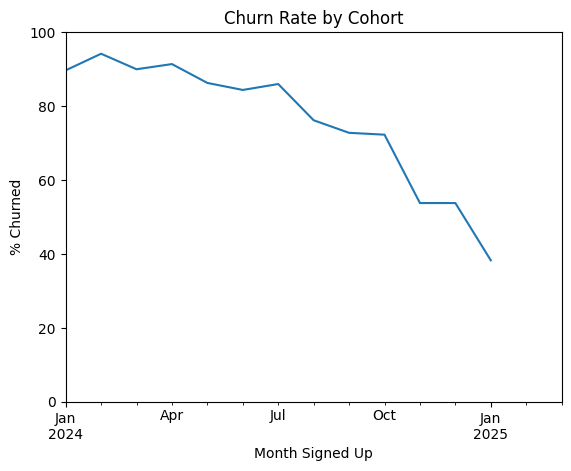

In [32]:
max_date = df.order_date.max()

cdf = pd.merge(df, customer_agg['Last Order Date'], on='customer_id')

cdf['is_churned'] = (max_date - cdf['Last Order Date']) >= '90 days'

is_churned_by_cohort = cdf.groupby(['month_cohort','is_churned']).customer_id.nunique().unstack()

churn_rate_by_cohort = is_churned_by_cohort.iloc[:,1] / is_churned_by_cohort.sum(axis=1)
churn_rate_by_cohort = churn_rate_by_cohort.apply(lambda x: round(x * 100, 1))
churn_rate_by_cohort.plot(title='Churn Rate by Cohort', xlabel='Month Signed Up', ylabel='% Churned',ylim=(0,100))
display()

# churn_rate_by_acquisition_channel.iloc[:,1] / churn_rate_by_acquisition_channel.sum(axis=1) * 100, 2)
    
# . \   plot(kind = 'bar', title='Churn Rate by Acquisition Channel', xlabel='Acquisition Channel', ylabel='% Churned')

Channel with Highest Churn Rate is: paid_search
Channel with Lowest Churn Rate is: referral


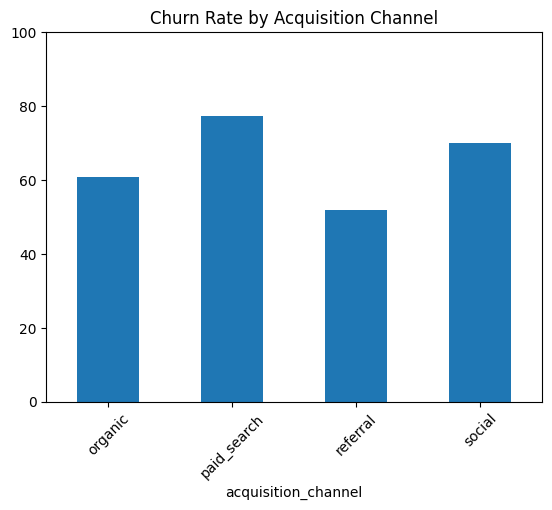

In [33]:
churn_rate_by_acquisition_channel = cdf.groupby(['acquisition_channel','is_churned']).customer_id.nunique().unstack()
churn_rate_by_acquisition_channel = churn_rate_by_acquisition_channel.iloc[:,1] / churn_rate_by_acquisition_channel.sum(axis=1)
churn_rate_by_acquisition_channel = churn_rate_by_acquisition_channel.apply(lambda x: round(x * 100, 1))
churn_rate_by_acquisition_channel.plot(kind='bar',xlim=1,rot=45, ylim=(0,100), title='Churn Rate by Acquisition Channel')
display()

print(f"Channel with Highest Churn Rate is: {churn_rate_by_acquisition_channel.idxmax()}")
print(f"Channel with Lowest Churn Rate is: {churn_rate_by_acquisition_channel.idxmin()}")

In [34]:
cdf = pd.merge(cdf, df.sort_values('order_date').groupby('customer_id').order_value.first().rename('First Order Value'), on='customer_id')


In [35]:
cdf.drop(columns=['order_value'], inplace=True)

Channel with Highest Churn Rate is: (0, 25]
Channel with Lowest Churn Rate is: (100, 125]


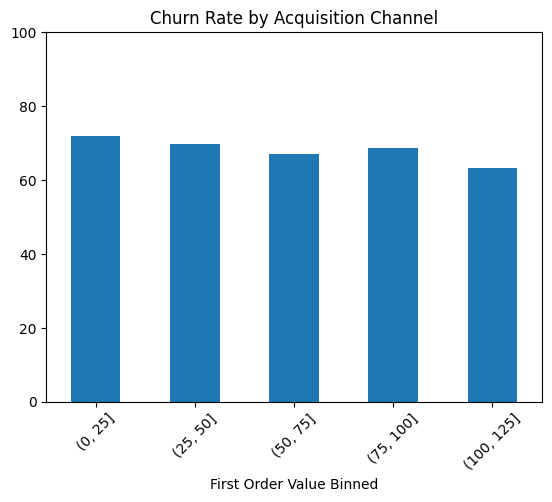

In [36]:
cdf['First Order Value Binned'] = pd.cut(cdf['First Order Value'], bins=range(0,150,25))

churn_rate_by_first_order_value = cdf.groupby(['First Order Value Binned','is_churned']).customer_id.nunique().unstack()
churn_rate_by_first_order_value = churn_rate_by_first_order_value.iloc[:,1] / churn_rate_by_first_order_value.sum(axis=1)



churn_rate_by_first_order_value = churn_rate_by_first_order_value.apply(lambda x: round(x * 100, 1))
churn_rate_by_first_order_value.plot(kind='bar',xlim=1,rot=45, ylim=(0,100), title='Churn Rate by Acquisition Channel')
display()

print(f"Channel with Highest Churn Rate is: {churn_rate_by_first_order_value.idxmax()}")
print(f"Channel with Lowest Churn Rate is: {churn_rate_by_first_order_value.idxmin()}")
